In [1]:
# Installation des packages

import sys

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install matplotlib tqdm seaborn scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 95.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 28.4 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 99.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 88.7 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [seaborn]1/12 [seaborn]ib]n]


In [2]:
import pandas as pd
import os
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import models
from PIL import Image
import os
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Téléchargement des données depuis le S3
!mc cp -r "s3/hlegarzic/stat_app/MINI-DDSM-Complete-JPEG-82/" "/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-82/" # données restructurées lors de l'entraînement du premier modèle
!mc cp "s3/hlegarzic/stat_app/breast-level_annotations.csv" "/home/onyxia/breast-level_annotations.csv"
!mc cp -r "s3/hlegarzic/stat_app/vindr_restructure/" "/home/onyxia/data/vindr/"
!mc cp -r "s3/hlegarzic/stat_app/vindr_transforme/" "/home/onyxia/data/vindr_transforme/"

# Chargement du modèle avec EWC
!mc cp "s3/hlegarzic/stat_app/best_resnet18_ewc.pth" "/home/onyxia/best_resnet18_ewc.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18()
model.fc = torch.nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("/home/onyxia/best_resnet18_ewc.pth", map_location=device))
model.eval().to(device)

# Chargement et filtrage des annotations VinDr
df = pd.read_csv("/home/onyxia/breast-level_annotations.csv")
df = df[df["view_position"] == "MLO"]
df = df[df["breast_birads"].isin(["BI-RADS 1", "BI-RADS 2", "BI-RADS 3", "BI-RADS 4", "BI-RADS 5"])]
df["label"] = (df["breast_birads"] == "BI-RADS 1").astype(int)  # 1=normal, 0=cancer

transform = transforms.Compose([
    transforms.Resize(( 700, 700)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

]11;?\mc: Configuration written to `/home/onyxia/.mc/config.json`. Please update your access credentials.
mc: Successfully created `/home/onyxia/.mc/share`.
mc: Initialized share uploads `/home/onyxia/.mc/share/uploads.json` file.
mc: Initialized share downloads `/home/onyxia/.mc/share/downloads.json` file.
...18_ewc.pth: 42.72 MiB / 42.72 MiB ┃▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓┃ 170.67 MiB/s 0s]11;?\]11;?\]11;?\]11;?\

/opt/python/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


['normal', 'cancer_benign']
Classes : ['cancer_benign', 'normal']
Nombre d'images : 3666


  0%|          | 0/115 [00:00<?, ?it/s]/opt/python/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 115/115 [08:02<00:00,  4.19s/it]

Test_Accuracy : 53.9007%


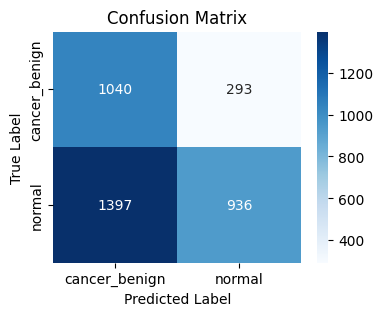

Rapport de classification : 
               precision    recall  f1-score   support

cancer_benign       0.43      0.78      0.55      1333
       normal       0.76      0.40      0.53      2333

     accuracy                           0.54      3666
    macro avg       0.59      0.59      0.54      3666
 weighted avg       0.64      0.54      0.54      3666



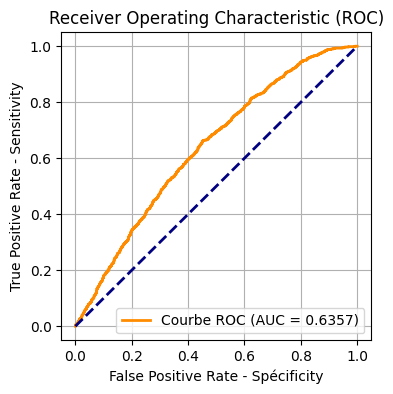

In [4]:
# Inférence sur DDSM

# Vérification de la structure du dossier
ddsm_path = "/home/onyxia/data/MINI-DDSM/MINI-DDSM-Complete-JPEG-82/"
print(os.listdir(ddsm_path))  # pour voir les sous-dossiers disponibles

test_dataset = ImageFolder(ddsm_path, transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"Classes : {test_dataset.classes}")
print(f"Nombre d'images : {len(test_dataset)}")

# Inférence
all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        probabilities = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities[:, 0].cpu().numpy())

predictions_np = np.array(all_predictions)
labels_np = np.array(all_labels)
probabilities_np = np.array(all_probabilities)

accuracy = np.mean(predictions_np == labels_np)
print(f'Test_Accuracy : {accuracy*100:.4f}%')

# Matrice de confusion
class_names = ['cancer_benign', 'normal']
cm = confusion_matrix(labels_np, predictions_np)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Rapport de classification
report = classification_report(labels_np, predictions_np, target_names=class_names)
print("Rapport de classification : ")
print(report)

# Courbe ROC et AUC
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(labels_np, probabilities_np, pos_label=0)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate - Spécificity')
plt.ylabel('True Positive Rate - Sensitivity')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

100%|██████████| 9999/9999 [51:51<00:00,  3.21it/s]  

Test Accuracy (VinDr restructuré) : 82.5283%


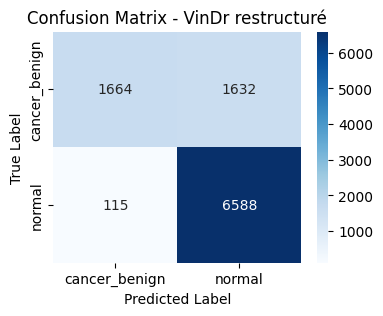

Rapport de classification (VinDr restructuré) :
               precision    recall  f1-score   support

cancer_benign       0.94      0.50      0.66      3296
       normal       0.80      0.98      0.88      6703

     accuracy                           0.83      9999
    macro avg       0.87      0.74      0.77      9999
 weighted avg       0.85      0.83      0.81      9999



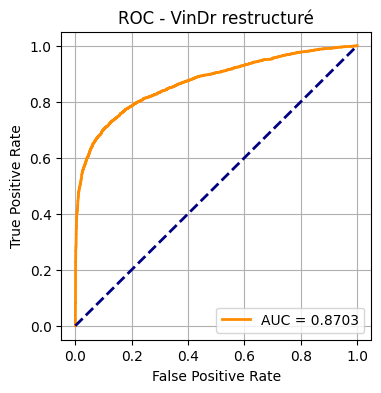

 59%|█████▉    | 5937/9999 [30:16<32:47,  2.06it/s]  

In [ ]:
# Inférence sur VinDr

def _print_metrics(predictions_np, labels_np, probabilities_np, titre):
    accuracy = np.mean(predictions_np == labels_np)
    print(f'Test Accuracy ({titre}) : {accuracy*100:.4f}%')

    class_names = ['cancer_benign', 'normal']
    cm = confusion_matrix(labels_np, predictions_np)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {titre}')
    plt.show()

    print(f"Rapport de classification ({titre}) :")
    print(classification_report(labels_np, predictions_np, target_names=class_names))

    fpr, tpr, _ = roc_curve(labels_np, probabilities_np, pos_label=0)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(4, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC - {titre}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

def run_inference_restructure(df, images_dir, model, transform, device, titre=""):
    all_predictions, all_labels, all_probabilities = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        classe = "normal" if row["label"] == 1 else "cancer_benign"
        img_path = os.path.join(images_dir, classe, row["image_id"] + ".png")
        if not os.path.exists(img_path):
            continue
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = model(img_tensor)
            probabilities = F.softmax(outputs, dim=1)
            _, pred = torch.max(outputs, 1)
            all_predictions.append(pred.item())
            all_labels.append(row["label"])
            all_probabilities.append(probabilities[0][0].item())
    _print_metrics(np.array(all_predictions), np.array(all_labels), np.array(all_probabilities), titre)

# ── VinDr restructuré (avant déplacement d'histogramme) ──
run_inference_restructure(df, "/home/onyxia/data/vindr/", model, transform, device, titre="VinDr restructuré")

# ── VinDr transformé (après déplacement d'histogramme) ──
run_inference_restructure(df, "/home/onyxia/data/vindr_transforme/", model, transform, device, titre="VinDr transformé")